In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    MaxPooling2D,
    AveragePooling2D
)

In [6]:
image = cv2.imread(
    "dog.jpg",
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    raise FileNotFoundError("Could not load the image.")

print("Image shape:", image.shape)

Image shape: (300, 332)


In [8]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

In [9]:
edge_x = cv2.filter2D(
    image.astype(np.float32),
    cv2.CV_32F,
    sobel_x
)

edge_y = cv2.filter2D(
    image.astype(np.float32),
    cv2.CV_32F,
    sobel_y
)

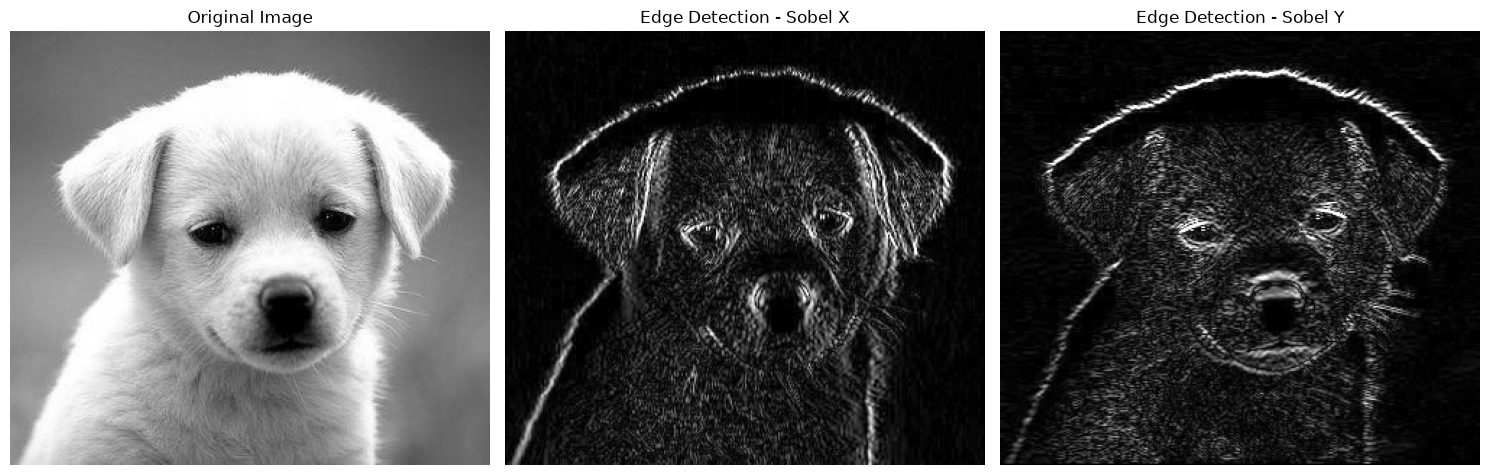

In [10]:
edge_x_display = cv2.convertScaleAbs(edge_x)
edge_y_display = cv2.convertScaleAbs(edge_y)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edge_x_display, cmap="gray")
plt.title("Edge Detection - Sobel X")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edge_y_display, cmap="gray")
plt.title("Edge Detection - Sobel Y")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
np.random.seed(10)

input_matrix = np.random.randint(
    1,
    10,
    size=(4, 4)
)

print("Original 4x4 Matrix:")
print(input_matrix)

Original 4x4 Matrix:
[[5 1 2 1]
 [2 9 1 9]
 [7 5 4 1]
 [5 7 9 2]]


In [13]:
input_tensor = input_matrix.astype(
    np.float32
).reshape(1, 4, 4, 1)

In [14]:
max_pool = MaxPooling2D(
    pool_size=(2, 2),
    strides=2
)

avg_pool = AveragePooling2D(
    pool_size=(2, 2),
    strides=2
)

In [15]:
max_pooled = max_pool(input_tensor)
avg_pooled = avg_pool(input_tensor)

In [16]:
max_pooled_matrix = max_pooled.numpy().squeeze()
avg_pooled_matrix = avg_pooled.numpy().squeeze()

In [17]:
print("\nMax Pooled Matrix:")
print(max_pooled_matrix)

print("\nAverage Pooled Matrix:")
print(avg_pooled_matrix)


Max Pooled Matrix:
[[9. 9.]
 [7. 9.]]

Average Pooled Matrix:
[[4.25 3.25]
 [6.   4.  ]]
